In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
print(df.duplicated().sum())

0


In [5]:
# Checking Imbalance dataset

print(df['Exited'].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64


In [6]:
print(df["Geography"].value_counts())

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


In [7]:
print(df["Gender"].value_counts())

Gender
Male      5457
Female    4543
Name: count, dtype: int64


In [8]:
df.drop(columns=["RowNumber","CustomerId","Surname"],inplace = True)

In [9]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
# One hot Encoding : Geography , Gender 

df = pd.get_dummies(df,columns=["Geography","Gender"],drop_first = True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [11]:
# Seperating data :

x = df.drop(columns = ["Exited"])
y = df["Exited"]

In [12]:
# train_test_split :

from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)


In [13]:
# Scalling :

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [14]:
# KERAS  : 

import tensorflow 
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

2026-03-19 09:43:32.422341: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773913412.697968      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773913412.777532      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773913413.402134      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773913413.402200      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773913413.402204      17 computation_placer.cc:177] computation placer alr

In [15]:
model = Sequential()

model.add(Dense(11,activation="relu",input_dim = 11)) # hidden layer
model.add(Dense(11,activation="relu"))
model.add(Dense(1,activation = "sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-19 09:44:02.530914: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# model compilation : 

model.compile(loss = 'binary_crossentropy',optimizer = "Adam",metrics=['accuracy'])

In [18]:
# model training :

history = model.fit(x_train_scaled,y_train,epochs = 50,validation_split=0.2)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7390 - loss: 0.5832 - val_accuracy: 0.7987 - val_loss: 0.4653
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7847 - loss: 0.4810 - val_accuracy: 0.8006 - val_loss: 0.4400
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7867 - loss: 0.4565 - val_accuracy: 0.8062 - val_loss: 0.4320
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8084 - loss: 0.4280 - val_accuracy: 0.8125 - val_loss: 0.4264
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8118 - loss: 0.4212 - val_accuracy: 0.8256 - val_loss: 0.4190
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8173 - loss: 0.4167 - val_accuracy: 0.8288 - val_loss: 0.4093
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8305 - loss: 0.4055 - val_accuracy: 0.8400 - val_loss: 0.4004
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8347 - loss: 0.4008 - val_accuracy: 0.

In [19]:
print("\n\nWeigths and biases layer 1\n\n" ,model.layers[0].get_weights())
print("\n\nWeigths and biases layer 2\n\n" ,model.layers[1].get_weights())
print("\n\nWeigths and biases layer 3\n\n" ,model.layers[2].get_weights())





Weigths and biases layer 1

 [array([[-0.0100654 , -0.01424203, -0.41398016,  0.30265468, -0.09880235,
         0.11924537,  0.32831588,  0.27965984, -0.09353781,  0.05808177,
        -0.07009289],
       [ 0.06892288,  0.913141  , -0.34013787, -0.1433941 ,  0.7630585 ,
        -0.4401704 , -0.14211711, -0.7481601 ,  0.8757161 , -0.04902185,
        -0.11540813],
       [ 0.3719897 ,  0.15487127,  0.12025529, -0.12525606,  0.01941495,
        -0.4039003 ,  0.1343843 , -0.33172756,  0.20608671,  0.22316697,
         0.33269966],
       [ 0.29692018,  0.00542757, -0.60248697,  0.27028263, -0.4341185 ,
        -0.3422994 , -0.49346924,  0.12929076, -0.4183442 , -0.25283885,
        -0.24555801],
       [ 0.5995305 ,  1.0665878 ,  0.2894676 ,  0.07209598, -1.027221  ,
         0.77915955, -0.12827466, -0.35029453, -0.17859139, -0.21049555,
        -0.5127444 ],
       [ 0.26063323, -0.2724427 ,  0.05151479, -0.00838013, -0.049699  ,
        -0.22663154, -0.19528098,  0.16028406,  0.11736

In [20]:
# prediction :

y_log = model.predict(x_test_scaled) # we used sigmoid so output is in [0,1]

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [21]:
# we used 0.5 as threshold above 0.5 prediction = 1 and below 0.5 prediction = 0

y_pred = np.where(y_log > 0.5 , 1 , 0) 

In [22]:
# Accuracy : for better accurracy 
#           1. Can increase number of nodes in layers , 
#           2. Can increase number of epoche
#           3. Can change activation function 
#           4. Can increase number of hidden layers

from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)*100

86.0

In [23]:
# Graphs :

import matplotlib.pyplot as plt

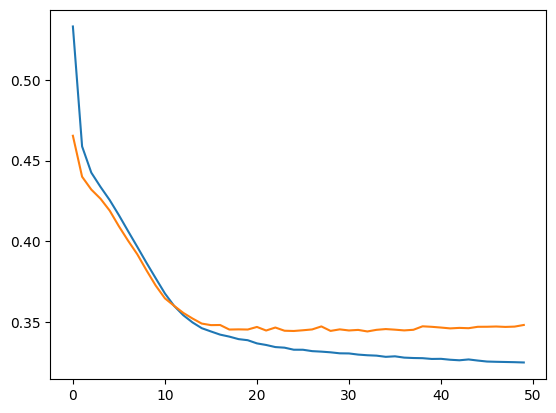

In [24]:
# more the gap between plots more the overfitting :

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.show()

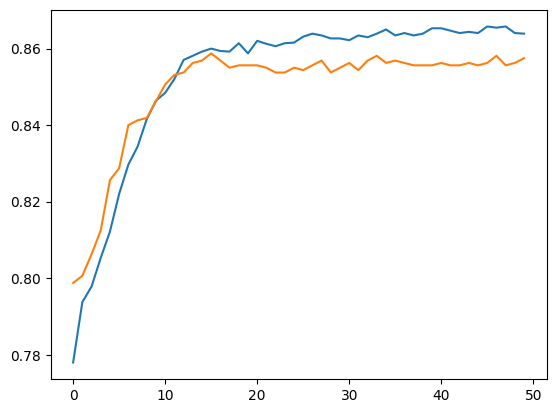

In [25]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.show()

In [26]:
# Clone repo
!git clone https://github.com/ayushpaliwal1920/Deep_Learning.git

# Go inside repo
%cd Deep_Learning

Cloning into 'Deep_Learning'...
fatal: unable to access 'https://github.com/ayushpaliwal1920/Deep_Learning.git/': Could not resolve host: github.com
[Errno 2] No such file or directory: 'Deep_Learning'
/kaggle/working
